# Análisis de resultados por modelos 


Como parte del proyecto de Big Data, se desarrolló un sistema de clasificación binaria orientado al análisis de reseñas hoteleras en Estados Unidos. El objetivo principal consiste en determinar si es posible predecir el sentimiento asociado a una reseña utilizando información textual generada por los huéspedes, complementada con variables geográficas derivadas de la ubicación del hotel.


La información utilizada proviene de la integración de dos fuentes de datos. La primera corresponde al conjunto de datos Datafiniti Hotel Reviews, el cual contiene miles de reseñas hoteleras junto con información asociada a los establecimientos y a las evaluaciones realizadas por los usuarios. La segunda fuente corresponde al dataset USA States to Region, que incorpora información contextual relacionada con la región y división geográfica de cada estado de Estados Unidos. Mediante el cruce de ambas fuentes fue posible enriquecer cada reseña con variables geográficas adicionales susceptibles de aportar valor predictivo.


La variable objetivo del problema corresponde al sentimiento de la reseña (sentiment), construida a partir de la calificación otorgada por el huésped. Las reseñas con calificaciones de 4 o 5 fueron clasificadas como positivas (valor 1), mientras que las reseñas con calificaciones de 1, 2 o 3 fueron clasificadas como negativas (valor 0). Esta transformación convierte el problema en una tarea de clasificación binaria supervisada, donde el modelo debe aprender patrones que permitan diferenciar ambos grupos.

Para la construcción de los modelos se emplearon como variables predictoras el contenido textual de las reseñas y variables geográficas derivadas del estado donde se ubica cada hotel. El texto fue transformado mediante técnicas de procesamiento de lenguaje natural basadas en TF-IDF, mientras que las variables categóricas de región y división fueron codificadas mediante One-Hot Encoding para incorporarlas al espacio de características utilizado durante el entrenamiento.

Se entrenaron y evaluaron dos algoritmos de aprendizaje autómatico utilizando las bibliotecas de Spark MLlib:

- Logistic Regression
- Random Forest

Ambos modelos fueron entrenados sobre la misma partición de datos (80% entrenamiento y 20% prueba)

La variable objetivo es **sentiment** , donde:

- **1:** representa una reseña positiva.
- **0:** representa una reseña negativa.

El objetivo de este notebook no es volver a entrenar los modelos, sino analizar los resultados generados previamente por el programa main_models.py. Para ello se utilizan las métricas de evaluación, matrices de confusión y predicciones almacenadas durante el proceso de entrenamiento.

In [31]:
import glob
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve, auc
import os
os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["hadoop.home.dir"] = "C:\\hadoop"
os.environ["PATH"] = "C:\\hadoop\\bin;" + os.environ["PATH"]

In [2]:
# Crear sesión de Spark para leer los archivos parquet de predicciones
spark = (
    SparkSession.builder
    .appName("Analisis-Modelos")
    .getOrCreate()
)

In [3]:
# Función auxiliar para leer carpetas CSV generadas por Spark.
# Spark no guarda un único archivo CSV, sino una carpeta con archivos part-*.csv.
def read_spark_csv_folder(path):
    file_path = glob.glob(f"{path}/part-*.csv")[0]
    return pd.read_csv(file_path)

In [4]:
# Rutas de resultados generados por main_models.py
results_path = "../../data/results"

metrics = read_spark_csv_folder(f"{results_path}/metrics_comparison.csv")
conf_lr = read_spark_csv_folder(f"{results_path}/confusion_matrix_lr.csv")
conf_rf = read_spark_csv_folder(f"{results_path}/confusion_matrix_rf.csv")
sentiment_region = read_spark_csv_folder(f"{results_path}/sentiment_by_region.csv")

pred_lr = spark.read.parquet(f"{results_path}/predictions_lr.parquet")
pred_rf = spark.read.parquet(f"{results_path}/predictions_rf.parquet")

In [5]:
# Visualización inicial de las métricas generadas
metrics

,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.792705,0.788684,0.792705,0.788567,0.838093
1,Random Forest,0.661351,0.770058,0.661351,0.536148,0.852699


## Distribución del sentimiento por región

In [ ]:
# Convertir conteos por región y sentimiento a tabla dinámica
sentiment_pivot = sentiment_region.pivot(
    index="region",
    columns="sentiment",
    values="count"
).fillna(0)

sentiment_pivot = sentiment_pivot.rename(columns={
    0: "Negativo",
    1: "Positivo"
})

sentiment_pivot

sentiment,Negativo,Positivo
region,,
Midwest,1486,2891
Northeast,1277,2207
South,3427,7084
West,2463,4765


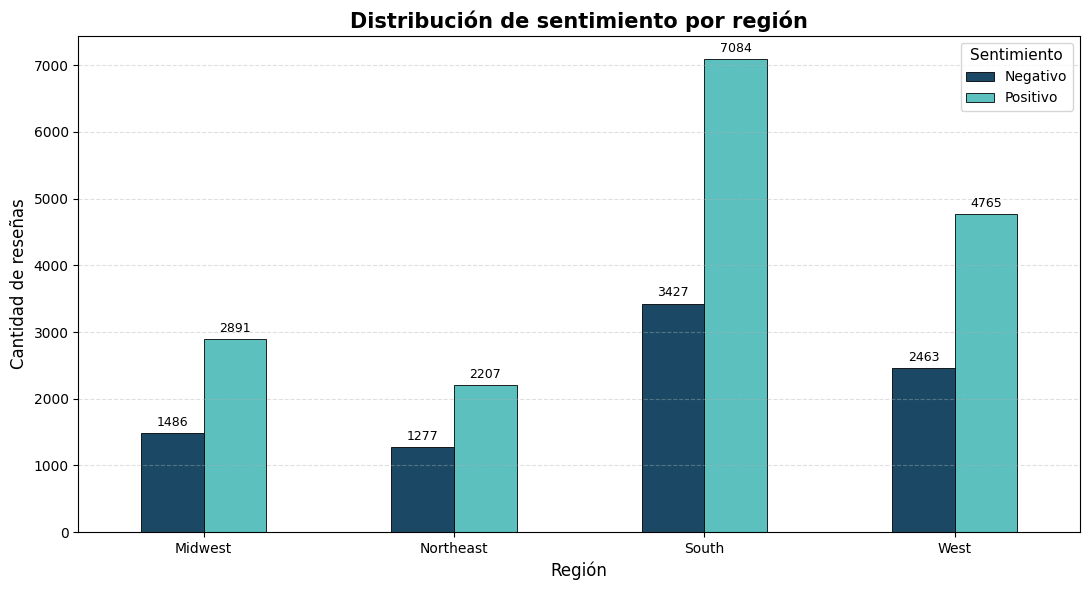

In [24]:
# Gráfico de distribución de sentimiento por región

colors = {
    "Negativo": "#1B4965", 
    "Positivo": "#5BC0BE"  
}

ax = sentiment_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    color=[colors["Negativo"], colors["Positivo"]],
    edgecolor="black",
    linewidth=0.6
)

plt.title("Distribución de sentimiento por región", fontsize=15, fontweight="bold")
plt.xlabel("Región", fontsize=12)
plt.ylabel("Cantidad de reseñas", fontsize=12)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    title="Sentimiento",
    fontsize=10,
    title_fontsize=11,
    frameon=True
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=9, padding=3)

plt.tight_layout()
plt.show()

Es importante destacar que el conjunto de datos presenta un desbalance moderado de clases, donde aproximadamente un 65% de las reseñas corresponden a opiniones positivas y un 35% a opiniones negativas. Esta característica puede influir en el comportamiento de los algoritmos, especialmente en métricas relacionadas con la capacidad de identificar correctamente la clase minoritaria.Dado lo anterior, se observa que al analizar la distribución de sentimiento, en las cuatro regiones analizadas, las reseñas positivas superan a las negativas, siendo consistente con el desbalance general del conjunto de datos.

La región South concentra la mayor cantidad de reseñas, tanto positivas como negativas, lo cual indica que tiene una mayor representación dentro del dataset. En segundo lugar se observa la región West, seguida por Midwest y Northeast. Por lo tanto, las diferencias absolutas entre regiones no deben interpretarse directamente como mayor o menor satisfacción, sino también como consecuencia de la cantidad de registros disponibles en cada zona.

Aun así, el patrón general permite observar que la proporción de reseñas positivas se mantiene superior en todas las regiones. Esto sugiere que la variable geográfica puede aportar contexto al análisis, aunque por sí sola no parece cambiar completamente la tendencia dominante del sentimiento. En otras palabras, la región puede ayudar a enriquecer el modelo, pero el contenido textual de la reseña sigue siendo el principal insumo predictivo para clasificar si una experiencia fue positiva o negativa.

# Modelo 1: Logistic Regression


Logistic Regression fue seleccionado como primer modelo de clasificación porque es uno de los algoritmos más utilizados en problemas de clasificación binaria, especialmente cuando los datos provienen de texto transformado en vectores numéricos. En este proyecto, las reseñas hoteleras fueron convertidas en variables numéricas mediante TF-IDF, técnica que representa la importancia relativa de las palabras dentro del conjunto de documentos. Este tipo de representación suele generar espacios de alta dimensionalidad, donde los modelos lineales como Logistic Regression tienden a funcionar de manera eficiente.

 Su objetivo es estimar la probabilidad de que una observación pertenezca a una clase determinada. En este caso, el modelo estima la probabilidad de que una reseña sea positiva o negativa a partir del contenido textual de la opinión y de las variables geográficas incorporadas al pipeline.



In [9]:
# Filtrar métricas de Logistic Regression
lr_metrics = metrics[metrics["model"] == "Logistic Regression"]
lr_metrics

,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.792705,0.788684,0.792705,0.788567,0.838093


In [25]:
# Preparar matriz de confusión en formato tabla
conf_lr_matrix = conf_lr.pivot(
    index="sentiment",
    columns="prediction",
    values="count"
).fillna(0)

conf_lr_matrix

prediction,0.0,1.0
sentiment,,
0,1102,644
1,396,2875


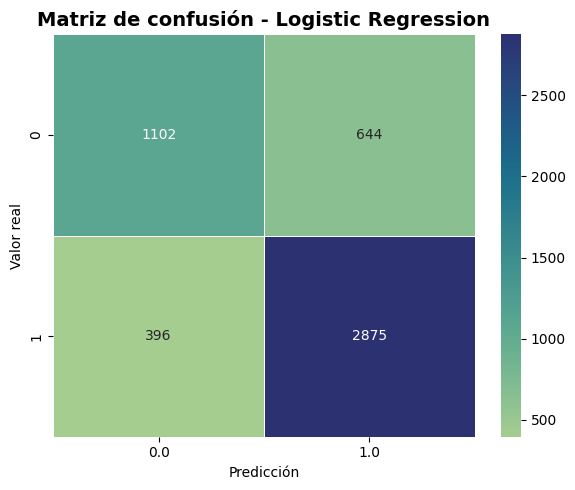

In [ ]:
#Visualización de la matriz de confusión para Logistic Regression
plt.figure(figsize=(6,5))

sns.heatmap(
    conf_lr_matrix,
    annot=True,
    fmt="d",
    cmap="crest", 
    cbar=True,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Matriz de confusión - Logistic Regression",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()
plt.show()

De las métricas obtenidas y de la matriz de confusión para la Regresión Logística se puede afirmar lo siguiente:

- El accuracy de 0.7927 indica que el modelo clasificó correctamente aproximadamente el 79.27% de las reseñas del conjunto de prueba. Esta métrica refleja el porcentaje total de aciertos, considerando tanto reseñas positivas como negativas. En términos generales, es un resultado adecuado para una primera aproximación al problema, especialmente considerando que el modelo trabaja con texto libre, una fuente de datos naturalmente variable y compleja.

- La precision de 0.7887 indica que, de las reseñas clasificadas por el modelo como pertenecientes a una clase, una proporción importante fue correctamente asignada. En este contexto, la precisión permite evaluar qué tan confiables son las predicciones realizadas por el modelo. Un valor cercano al 79% sugiere que Logistic Regression mantiene un nivel razonable de exactitud al momento de asignar las etiquetas de sentimiento.

- El recall de 0.7927 muestra la capacidad del modelo para recuperar correctamente las observaciones reales de cada clase. Esta métrica es especialmente importante cuando interesa no solamente acertar en términos generales, sino también identificar adecuadamente las reseñas positivas y negativas existentes en los datos. En este caso, el recall es muy similar al accuracy, lo cual sugiere un comportamiento relativamente equilibrado.

- El F1-score de 0.7886 resume el balance entre precision y recall. Esta métrica es particularmente útil cuando existe desbalance entre clases, como ocurre en este proyecto, donde aproximadamente el 65% de las reseñas son positivas y el 35% negativas. El valor obtenido indica que el modelo logra mantener un buen equilibrio entre clasificar correctamente y no favorecer de manera excesiva una sola clase.

E- l AUC-ROC de 0.8381 indica que el modelo tiene una buena capacidad para distinguir entre reseñas positivas y negativas a distintos umbrales de decisión. Un valor superior a 0.80 suele interpretarse como una señal positiva, ya que significa que las probabilidades generadas por el modelo separan razonablemente bien ambas clases.

Por otra parte, la matriz de confusión permite analizar con mayor detalle el comportamiento del modelo. Logistic Regression clasificó correctamente 1102 reseñas negativas y 2875 reseñas positivas. Además, cometió 644 falsos positivos, es decir, reseñas negativas que fueron clasificadas como positivas, y 396 falsos negativos, reseñas positivas clasificadas como negativas.

Estos resultados muestran que el modelo identifica correctamente una cantidad importante de observaciones en ambas clases. Aunque existe una mayor cantidad de reseñas positivas correctamente clasificadas, esto también está relacionado con la distribución original del dataset, donde la clase positiva tiene mayor presencia. Aun así, el modelo no ignora la clase negativa, ya que logra reconocer 1102 reseñas negativas correctamente, lo cual es relevante considerando que esta clase es minoritaria.

En conjunto, Logistic Regression presenta un desempeño sólido y balanceado. Sus métricas son consistentes entre sí y la matriz de confusión evidencia que el modelo no se limita a predecir únicamente la clase mayoritaria. Esto lo convierte en un modelo adecuado para el problema de predicción de sentimiento planteado en el proyecto.

# Modelo 2: Random Forest

Random Forest fue seleccionado como segundo modelo de clasificación debido a que representa un enfoque significativamente diferente a Logistic Regression. Mientras que Logistic Regression construye una única frontera de decisión lineal, Random Forest utiliza un conjunto de árboles de decisión que trabajan de manera conjunta para realizar la clasificación final.

Este algoritmo pertenece a la familia de métodos de ensamblado (ensemble learning), donde múltiples modelos individuales son combinados para obtener una predicción más robusta. Cada árbol del bosque se construye utilizando una muestra aleatoria de los datos y una selección aleatoria de variables, reduciendo el riesgo de sobreajuste y aumentando la capacidad de generalización.

En el contexto de este proyecto, Random Forest resulta particularmente interesante porque puede capturar relaciones no lineales entre las características generadas por TF-IDF y las variables geográficas incorporadas al modelo. Esto permite evaluar si existen patrones complejos de comportamiento que no puedan ser identificados por un modelo lineal tradicional. Sin embargo, en este proyecto particular, es importante destacar la posibilidad de presentar sesgos hacia la clase mayoritaria cuando existe un desbalance en los datos conjutno a que en problemas de texto representado mediante TF-IDF, el espacio de características puede ser muy grande y disperso. Esto puede dificultar que los árboles encuentren divisiones efectivas, especialmente cuando existe desbalance entre clases.

In [13]:
# Filtrar métricas de Random Forest
rf_metrics = metrics[metrics["model"] == "Random Forest"]
rf_metrics

,model,accuracy,precision,recall,f1,auc_roc
1,Random Forest,0.661351,0.770058,0.661351,0.536148,0.852699


In [15]:
# Preparar matriz de confusión en formato tabla
conf_rf_matrix = conf_rf.pivot(
    index="sentiment",
    columns="prediction",
    values="count"
).fillna(0)

conf_rf_matrix

prediction,0.0,1.0
sentiment,,
0,48,1698
1,1,3270


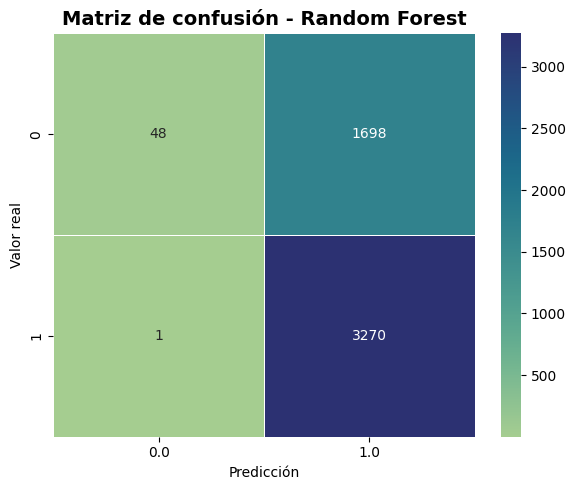

In [32]:
# Visualización de la matriz de confusión para Random Forest
plt.figure(figsize=(6,5))

sns.heatmap(
    conf_rf_matrix,
    annot=True,
    fmt="d",
    cmap="crest",
    cbar=True,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Matriz de confusión - Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()
plt.show()

De las métricas obtenidas y de la matriz de confusión para el modelo de Random Forest se puede afirmar lo siguiente:


- El accuracy obtenido indica que aproximadamente el 66.14% de las reseñas fueron clasificadas correctamente. Esto significa que cerca de dos tercios de las observaciones recibieron una predicción correcta por parte del modelo. Aunque este resultado es aceptable, evidencia que existe una cantidad considerable de errores de clasificación.

- La precision de 0.7701 indica que cuando el modelo realiza una predicción, aproximadamente el 77% de ellas corresponden efectivamente a la clase asignada. Este valor sugiere que las predicciones generadas poseen un nivel razonable de confiabilidad.

- El recall de 0.6614 refleja la capacidad del modelo para identificar correctamente las observaciones reales de cada clase. Un valor cercano al 66% muestra que una proporción importante de registros no está siendo correctamente recuperada durante el proceso de clasificación.

- El F1-score de 0.5361 representa el equilibrio entre precision y recall. Esta métrica resulta especialmente relevante debido al desbalance existente entre reseñas positivas y negativas dentro del conjunto de datos. El valor obtenido evidencia que, aunque el modelo presenta una precisión relativamente alta, el balance general entre ambas métricas es limitado.

- Finalmente, el AUC-ROC de 0.8527 muestra una capacidad de discriminación relativamente buena entre ambas clases. Esto indica que el modelo genera probabilidades capaces de separar razonablemente bien las reseñas positivas de las negativas cuando se consideran distintos umbrales de decisión.

Random Forest presentó un comportamiento distinto al de Logistic Regression. Aunque obtuvo un AUC-ROC ligeramente mayor, la matriz de confusión muestra que el modelo clasificó la mayoría de observaciones como positivas. Esto provocó una baja capacidad para identificar reseñas negativas.

Este resultado puede estar asociado al desbalance de clases, donde como se mencionó anteriormente, aproximadamente 65% de las reseñas corresponden a la clase positiva y 35% a la clase negativa. Además, el uso de TF-IDF genera un espacio de características muy amplio y disperso, lo cual no siempre favorece el desempeño de modelos basados en árboles.

## CURVAS ROC

Las curvas ROC permiten comparar la capacidad de los modelos para separar las clases positiva y negativa a distintos umbrales de clasificación. Para construirlas se utilizan las probabilidades estimadas por cada modelo.

In [18]:
# Convertir predicciones de Spark a pandas para construir las curvas ROC
lr_pd = pred_lr.select("sentiment", "probability").toPandas()
rf_pd = pred_rf.select("sentiment", "probability").toPandas()

# Extraer probabilidad de la clase positiva
lr_y_true = lr_pd["sentiment"]
lr_y_score = lr_pd["probability"].apply(lambda x: float(x[1]))

rf_y_true = rf_pd["sentiment"]
rf_y_score = rf_pd["probability"].apply(lambda x: float(x[1]))

# Calcular curvas ROC y AUC
fpr_lr, tpr_lr, _ = roc_curve(lr_y_true, lr_y_score)
fpr_rf, tpr_rf, _ = roc_curve(rf_y_true, rf_y_score)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

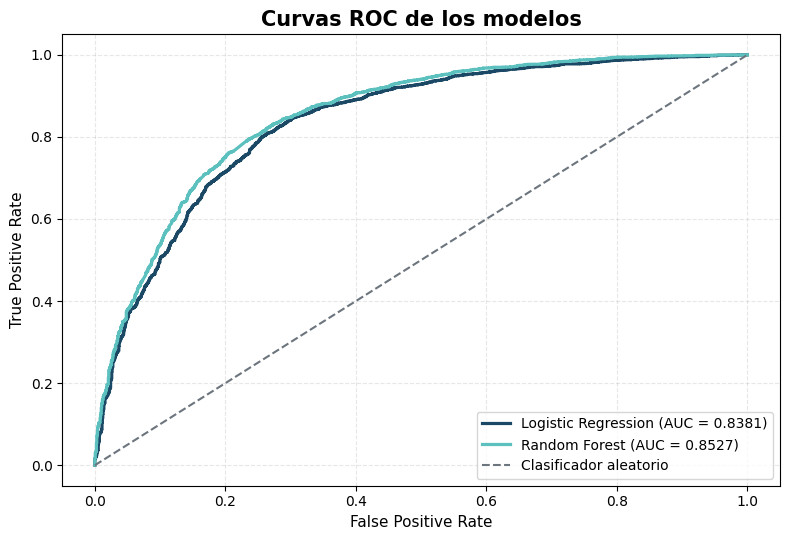

In [33]:
# Visualizar ambas curvas ROC
plt.figure(figsize=(8, 5.5))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})",
    color="#1B4965",
    linewidth=2.3
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})",
    color="#5BC0BE",
    linewidth=2.3
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#6C757D",
    linewidth=1.5,
    label="Clasificador aleatorio"
)

plt.title(
    "Curvas ROC de los modelos",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)

plt.grid(alpha=0.3, linestyle="--")

plt.legend(
    loc="lower right",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

Como se mencionó anteriormente, la curva ROC permite evaluar la capacidad de cada modelo para separar las reseñas positivas de las negativas considerando distintos umbrales de clasificación. En este gráfico, el eje horizontal representa la tasa de falsos positivos, mientras que el eje vertical representa la tasa de verdaderos positivos. La línea diagonal punteada representa un clasificador aleatorio; por lo tanto, mientras más alejada esté la curva de esa diagonal y más cercana se encuentre a la esquina superior izquierda, mejor será la capacidad discriminativa del modelo.

Al observar el gráfico, ambos modelos presentan curvas claramente superiores a la línea aleatoria, lo que indica que los dos lograron aprender patrones útiles para distinguir entre reseñas positivas y negativas. Logistic Regression obtuvo un AUC-ROC de 0.8381, mientras que Random Forest obtuvo un AUC-ROC de 0.8527. Esto significa que, al evaluar la capacidad de separación de clases a distintos umbrales, Random Forest presenta una ligera ventaja.

Sin embargo, esta diferencia debe interpretarse con cuidado. El AUC-ROC mide la capacidad general de ordenamiento o separación probabilística, pero no necesariamente refleja el comportamiento final del modelo cuando se utiliza un umbral específico para convertir probabilidades en clases. En otras palabras, un modelo puede tener buen AUC porque asigna probabilidades relativamente ordenadas, pero aun así producir una clasificación final poco equilibrada.

En este caso, Random Forest alcanza un AUC ligeramente mayor, lo cual sugiere que sus probabilidades contienen información útil para separar las clases. No obstante, su matriz de confusión mostró una fuerte tendencia a clasificar reseñas como positivas, generando muchos falsos positivos. Por eso, aunque su curva ROC es competitiva, el análisis no debe basarse únicamente en AUC.

Logistic Regression, por su parte, obtiene un AUC levemente menor, pero mantiene un comportamiento más estable al momento de clasificar ambas clases. Su curva también se mantiene claramente por encima de la diagonal, lo que confirma que posee buena capacidad predictiva. En conjunto, la curva ROC muestra que ambos modelos tienen poder discriminativo, pero debe complementarse con métricas como F1-score, recall, precision y matriz de confusión para tomar una decisión más completa.

# Comparación de modelos


En esta sección se comparan ambos modelos utilizando las métricas generadas por `main_models.py`. Las métricas consideradas son Accuracy, Precision, Recall, F1-score y AUC-ROC.

In [20]:
metrics

,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.792705,0.788684,0.792705,0.788567,0.838093
1,Random Forest,0.661351,0.770058,0.661351,0.536148,0.852699


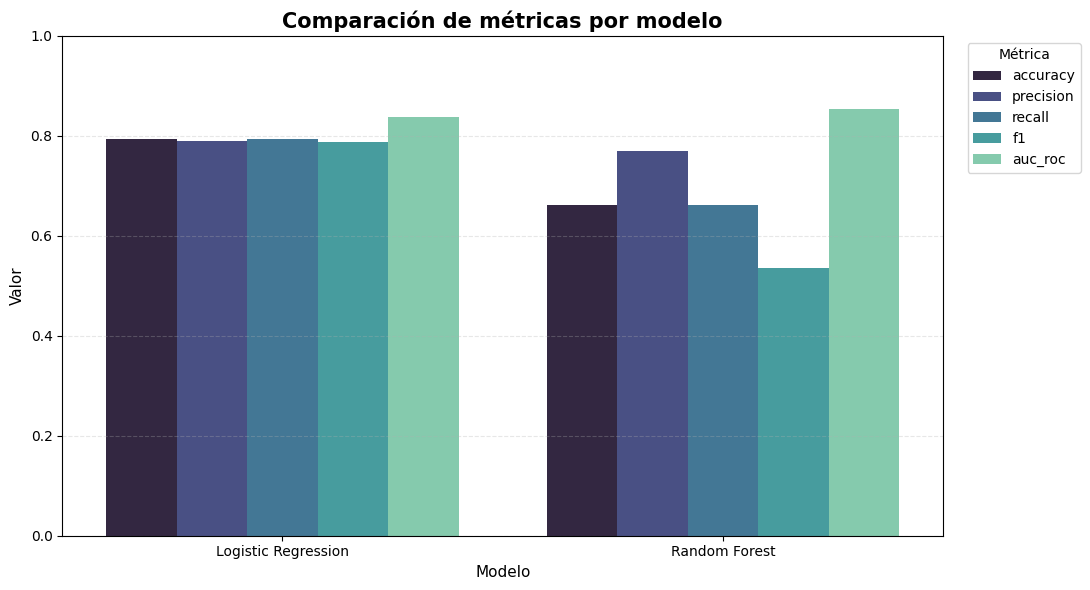

In [34]:
# Gráfico comparativo de métricas
metrics_long = metrics.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "auc_roc"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=metrics_long,
    x="model",
    y="Valor",
    hue="Métrica",
    palette="mako"
)

plt.title(
    "Comparación de métricas por modelo",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Modelo", fontsize=11)
plt.ylabel("Valor", fontsize=11)
plt.ylim(0, 1)

plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

La comparación general de métricas permite evaluar el desempeño de ambos modelos desde diferentes perspectivas. En este caso, se consideran cinco métricas: accuracy, precision, recall, F1-score y AUC-ROC. Cada una aporta información distinta sobre la calidad del modelo, por lo que la selección del mejor algoritmo no debe basarse en una única medida. De la visualización anterior se puede afirmar lo siguiente:

- Logistic Regression obtuvo un accuracy de 0.7927, superior al 0.6614 alcanzado por Random Forest. Esto indica que Logistic Regression clasificó correctamente una mayor proporción total de reseñas dentro del conjunto de prueba. En términos generales, este resultado muestra que el modelo lineal logró adaptarse mejor al problema de clasificación de sentimiento planteado.

- En precision, Logistic Regression también obtuvo un resultado ligeramente superior, con 0.7887 frente a 0.7701 de Random Forest. Aunque la diferencia no es tan amplia como en otras métricas, indica que las predicciones realizadas por Logistic Regression fueron levemente más confiables en términos de aciertos sobre las clases asignadas.

- La diferencia más importante aparece en recall y F1-score. Logistic Regression alcanzó un recall de 0.7927, mientras que Random Forest obtuvo 0.6614. Esto indica que Logistic Regression tuvo mayor capacidad para recuperar correctamente las observaciones reales de las clases evaluadas. El F1-score confirma esta diferencia: Logistic Regression obtuvo 0.7886, mientras que Random Forest alcanzó únicamente 0.5361. Esta métrica es especialmente relevante porque combina precision y recall, y resulta útil cuando existe desbalance de clases, como ocurre en este proyecto.

- El resultado de F1-score evidencia que Logistic Regression mantuvo un mejor balance entre precisión y cobertura de las clases. En cambio, Random Forest presentó un desempeño menos equilibrado, principalmente porque tendió a clasificar una gran parte de las observaciones como positivas. Esto afectó su capacidad para identificar correctamente reseñas negativas y redujo considerablemente su F1-score.

- El único indicador donde Random Forest supera a Logistic Regression es el AUC-ROC, con 0.8527 frente a 0.8381. Esto indica que Random Forest tuvo una capacidad ligeramente mayor para ordenar probabilísticamente las observaciones según su pertenencia a la clase positiva o negativa. Sin embargo, este resultado debe interpretarse junto con las demás métricas y la matriz de confusión. Un AUC alto no garantiza necesariamente una mejor clasificación final cuando el modelo utiliza un umbral específico para asignar clases.

- En conjunto, Logistic Regression presenta el mejor desempeño operativo para este problema. Aunque Random Forest muestra una ligera ventaja en AUC-ROC, Logistic Regression ofrece resultados más consistentes en accuracy, precision, recall y F1-score. Además, su matriz de confusión evidencia un comportamiento más balanceado entre reseñas positivas y negativas.

- Este resultado es coherente con la naturaleza del problema. La clasificación de texto mediante TF-IDF genera un espacio de características amplio y disperso, escenario en el que los modelos lineales suelen desempeñarse adecuadamente. Random Forest, aunque es más flexible y capaz de capturar relaciones no lineales, puede verse afectado por la alta dimensionalidad del texto y por el desbalance de clases presente en el dataset.

-Por lo tanto, considerando el conjunto completo de métricas y no únicamente el AUC-ROC, Logistic Regression se considera el modelo con mejor desempeño general para la predicción del sentimiento de reseñas hoteleras.

## Conclusiones

- El desarrollo de los modelos de clasificación permitió comprobar que es posible predecir el sentimiento de una reseña hotelera utilizando información textual y variables contextuales asociadas a la ubicación geográfica de los hoteles. Los resultados obtenidos evidencian que las técnicas de procesamiento de lenguaje natural basadas en TF-IDF, combinadas con algoritmos de aprendizaje automático de Spark MLlib, logran capturar patrones relevantes dentro de las opiniones escritas por los usuarios.

- A partir de las métricas evaluadas, Logistic Regression obtuvo el mejor desempeño general. Este modelo alcanzó mayores valores de accuracy, precision, recall y F1-score, mostrando un comportamiento más equilibrado al momento de clasificar tanto reseñas positivas como negativas. Su matriz de confusión evidenció una mejor capacidad para identificar ambas clases, reduciendo la cantidad de errores de clasificación en comparación con Random Forest.

- Por su parte, Random Forest obtuvo el mayor valor de AUC-ROC, lo que indica una buena capacidad para separar probabilísticamente las observaciones de ambas clases. Sin embargo, al utilizar un umbral de decisión para realizar la clasificación final, el modelo mostró una fuerte tendencia a predecir reseñas positivas, afectando significativamente su desempeño en términos de recall para la clase negativa y reduciendo considerablemente su F1-score.

- Los resultados sugieren que, para este tipo de problema basado principalmente en texto representado mediante vectores TF-IDF de alta dimensionalidad, los modelos lineales como Logistic Regression pueden adaptarse mejor que modelos basados en árboles. Esto se debe a que los espacios de características generados por texto suelen ser muy dispersos y contienen miles de variables, un escenario donde los modelos lineales suelen ofrecer un desempeño compe


In [22]:
spark.stop()